In [1]:
from pathlib import Path
import os

print("CURRENT WORKING DIRECTORY:\n")
print(os.getcwd())
import os

# Tell LangGraph exactly which modules are safe to serialize
os.environ["LANGGRAPH_ALLOWED_MSGPACK_MODULES"] = (
    "layer_2_refund.schemas.refund_models,"
    "layer_2_refund.graphs.refund_state"
)

# ... then re-compile your graph (Block 2)

CURRENT WORKING DIRECTORY:

c:\Users\Shiwan\OneDrive\Desktop\multi_agent_customer_support_system\layer_2_refund


In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

c:\Users\Shiwan\OneDrive\Desktop\multi_agent_customer_support_system


In [3]:
# =====================================================
# BLOCK 1 — IMPORTS
# =====================================================

import uuid

from langgraph.checkpoint.memory import MemorySaver

from layer_2_refund.graphs.refund_graph import (
    refund_graph
)

from layer_2_refund.graphs.state_factory import (
    create_initial_refund_state
)

from layer_2_refund.schemas.refund_models import (
    RefundRequest
)

from layer_2_refund.mappers.refund_output_mapper import (
    build_refund_output
)

from layer_2_refund.database.session import (
    SessionLocal
)

c:\Users\Shiwan\OneDrive\Desktop\multi_agent_customer_support_system\venv\Lib\site-packages\langgraph\checkpoint\serde\encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [4]:
# =====================================================
# BLOCK 2
# =====================================================

app = refund_graph

print("✅ Graph loaded successfully.")

✅ Graph loaded successfully.


In [5]:
# =====================================================
# BLOCK 3 — CREATE TEST REQUEST
# =====================================================

request = RefundRequest(

    ticket_id=f"TKT-{uuid.uuid4().hex[:4]}",

    customer_id=3,

    order_id=3,

    reason_for_refund="Product arrived damaged"
)

print("✅ Request created")

print(request)

✅ Request created
ticket_id='TKT-1798' order_id=3 customer_id=3 reason_for_refund='Product arrived damaged'


In [6]:
# =====================================================
# BLOCK 4 — CREATE INITIAL STATE
# =====================================================

idempotency_key = (
    f"IDEM-{uuid.uuid4().hex[:8]}"
)

initial_state = create_initial_refund_state(
    request=request,
    idempotency_key=idempotency_key
)

config = {
    "configurable": {
        "thread_id": str(uuid.uuid4())
    }
}

print("✅ Initial state created.")

✅ Initial state created.


In [7]:
initial_state.keys()

dict_keys(['workflow_id', 'idempotency_key', 'state_version', 'request', 'order_data', 'customer_data', 'policy_decision', 'execution_result', 'human_decision', 'review_status', 'workflow_logs', 'current_node', 'metrics', 'audit_status', 'error_message'])

In [8]:
# =====================================================
# BLOCK 5 — EXECUTE WORKFLOW UNTIL INTERRUPT
# =====================================================

print("\n🚀 Starting Workflow...\n")

for event in app.stream(
    initial_state,
    config,
    stream_mode="values"
):

    current_node = event.get(
        "current_node",
        "UNKNOWN"
    )

    decision = event.get(
        "policy_decision"
    )

    if decision:

        print(
            f"Node={current_node} | "
            f"Status={decision.status.value.upper()} | "
            f"Code={decision.code}"
        )

    else:

        print(
            f"Node={current_node}"
        )

print("\n✅ Workflow paused or completed.")


🚀 Starting Workflow...



Router | Route=ESCALATION | Workflow=WF-0b920bda
Escalation Node | Status=ALERT_TRIGGERED | Workflow=WF-0b920bda | Key=IDEM-fb64add4 | Ticket=TKT-1798 | Reason=FRAUD_RISK_DETECTED | TargetQueue=Support_Lead_Queue


Node=START
Node=idempotency_node
Node=order_node
Node=customer_node
Node=policy_node | Status=ESCALATED | Code=FRAUD_RISK_DETECTED
Node=escalation_node | Status=ESCALATED | Code=FRAUD_RISK_DETECTED

✅ Workflow paused or completed.


In [9]:
# =====================================================
# BLOCK 6 — INSPECT INTERRUPTED STATE
# =====================================================

snapshot = app.get_state(config)

print("📌 NEXT NODE:")
print(snapshot.next)

print("\n📌 CURRENT REVIEW STATUS:")
print(snapshot.values.get("review_status"))

print("\n📌 CURRENT POLICY DECISION:")
print(snapshot.values.get("policy_decision"))

Deserializing unregistered type layer_2_refund.schemas.refund_models.RefundRequest from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('layer_2_refund.schemas.refund_models', 'RefundRequest')]
Deserializing unregistered type layer_2_refund.schemas.refund_models.OrderStatus from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('layer_2_refund.schemas.refund_models', 'OrderStatus')]
Deserializing unregistered type layer_2_refund.schemas.refund_models.OrderData from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('layer_2_refund.schemas.refund_models', 'OrderData')]
Deserializing unregistered type layer_2_refund.schemas.refund_models.CustomerData from checkpoint

📌 NEXT NODE:
('human_review_node',)

📌 CURRENT REVIEW STATUS:
PENDING

📌 CURRENT POLICY DECISION:
status=<RefundStatus.ESCALATED: 'escalated'> code='FRAUD_RISK_DETECTED' reason='Automated risk flags triggered based on account history/behavior.' refund_amount=None requires_human_review=True metadata={'review_queue': 'Support_Lead_Queue', 'escalated_by_node': 'policy_node'}


In [10]:
# =====================================================
# BLOCK 7 — SIMULATE HUMAN APPROVAL
# =====================================================

app.update_state(

    config,

    {

        "human_decision": "APPROVE",

        "review_status": "COMPLETED"
    }
)

print("✅ Human decision injected.")

✅ Human decision injected.


In [11]:
# =====================================================
# BLOCK 8 — RESUME WORKFLOW
# =====================================================

print("\n▶️ Resuming Workflow...\n")

for event in app.stream(

    None,

    config,

    stream_mode="values"
):

    current_node = event.get(
        "current_node",
        "UNKNOWN"
    )

    decision = event.get(
        "policy_decision"
    )

    if decision:

        print(
            f"Node={current_node} | "
            f"Status={decision.status.value.upper()} | "
            f"Code={decision.code}"
        )

    else:

        print(
            f"Node={current_node}"
        )


▶️ Resuming Workflow...

Node=escalation_node | Status=ESCALATED | Code=FRAUD_RISK_DETECTED
Node=human_review_node | Status=APPROVED | Code=HUMAN_APPROVED
Node=execution_node | Status=COMPLETED | Code=REFUND_EXECUTED


Node=audit_node | Status=COMPLETED | Code=REFUND_EXECUTED


In [12]:
# =====================================================
# BLOCK 9 — FINAL STATE INSPECTION
# =====================================================

final_state = app.get_state(config).values

print("🏁 FINAL DECISION:\n")

print(final_state.get("policy_decision"))

print("\n🏁 AUDIT STATUS:\n")

print(final_state.get("audit_status"))

print("\n🏁 REVIEW STATUS:\n")

print(final_state.get("review_status"))

Deserializing unregistered type layer_2_refund.schemas.refund_models.RefundExecutionResult from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('layer_2_refund.schemas.refund_models', 'RefundExecutionResult')]


🏁 FINAL DECISION:

status=<RefundStatus.COMPLETED: 'completed'> code='REFUND_EXECUTED' reason='Human Review Result: APPROVE' refund_amount=None requires_human_review=False metadata={'review_queue': 'Support_Lead_Queue', 'escalated_by_node': 'policy_node', 'human_review_decision': 'APPROVE', 'transaction_id': 'TXN-4FD371B3'}

🏁 AUDIT STATUS:

SUCCESS

🏁 REVIEW STATUS:

COMPLETED


In [13]:
# =====================================================
# BLOCK 10 — PRINT WORKFLOW LOGS
# =====================================================

print("\n📜 WORKFLOW LOGS\n")

for log in final_state.get(
    "workflow_logs",
    []
):

    print(log)


📜 WORKFLOW LOGS

Workflow Initialized | Workflow=WF-0b920bda
Idempotency Node | Status=MISS | Workflow=WF-0b920bda | Key=IDEM-fb64add4
Order Node | Status=SUCCESS | Workflow=WF-0b920bda | Key=IDEM-fb64add4 | Order=3
Customer Node | Status=SUCCESS | Workflow=WF-0b920bda | Key=IDEM-fb64add4 | Customer=1
Policy Node | Status=ESCALATED | Code=FRAUD_RISK_DETECTED | Workflow=WF-0b920bda | Key=IDEM-fb64add4
Escalation Node | Status=ALERT_TRIGGERED | Workflow=WF-0b920bda | Key=IDEM-fb64add4 | Ticket=TKT-1798 | Reason=FRAUD_RISK_DETECTED | TargetQueue=Support_Lead_Queue
Human Node | Status=RESOLVED | Workflow=WF-0b920bda | Key=IDEM-fb64add4 | Action=HUMAN_APPROVED
Execution Node | Status=STARTING | Workflow=WF-0b920bda | Key=IDEM-fb64add4 | Order=3 | Method=MockStripe
Execution Node | Status=SUCCESS | Workflow=WF-0b920bda | Key=IDEM-fb64add4 | TxnID=TXN-4FD371B3
Audit Node | Status=STARTING | Workflow=WF-0b920bda | Key=IDEM-fb64add4 | Ticket=TKT-1798
Audit Node | Status=SUCCESS | Workflow=WF-0

In [14]:
# =====================================================
# BLOCK 11 — PRINT METRICS
# =====================================================

metrics = final_state.get("metrics")

print("\n📊 WORKFLOW METRICS\n")

print(metrics)


📊 WORKFLOW METRICS

started_at=1780909707.5682724 completed_at=1780909707.9962492 duration_ms=427 retry_count=0


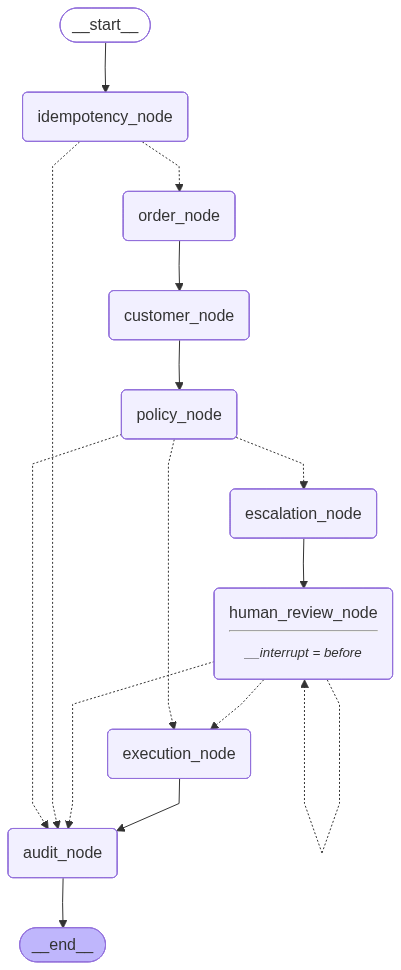

In [15]:
# =====================================================
# BLOCK 12 — VISUALIZE GRAPH
# =====================================================

from IPython.display import Image, display

display(

    Image(

        app.get_graph().draw_mermaid_png()
    )
)

In [16]:
final_state = app.get_state(
    config
).values

refund_output = build_refund_output(
    final_state
)

print(refund_output.model_dump())

{'ticket_id': 'TKT-1798', 'workflow_id': 'WF-0b920bda', 'customer_id': 3, 'order_id': 3, 'final_status': <RefundStatus.COMPLETED: 'completed'>, 'decision_code': 'REFUND_EXECUTED', 'decision_reason': 'Human Review Result: APPROVE', 'refund_amount': None, 'transaction_id': 'TXN-4FD371B3', 'review_required': False, 'review_status': 'COMPLETED', 'audit_status': 'SUCCESS', 'duration_ms': 427}
